# Entregable — Análisis de Componentes Principales (PCA)

**Curso:** Ciencias de los Datos para las Finanzas, la Economía y los Negocios  
**Dataset:** `pca_base.csv` — 3 844 encuestados, 8 variables sociodemográficas, 0 NAs  
**Variable de etiqueta:** `propension_12m` (1 = consumidor en últimos 12 meses)

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── rutas ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CSV_PATH = PROJECT_ROOT / 'data' / 'processed' / 'pca_base.csv'

# ── estilo ───────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
C0, C1 = '#534AB7', '#D85A30'   # consumidor / no consumidor

print('Librerías OK')
print(f'Dataset: {CSV_PATH}')


Librerías OK
Dataset: /Users/santi/Documents/EAFIT/2026-1/Ciencia de los Datos/Repo/colombia-marijuana-revenue-model/data/processed/pca_base.csv


## 1. Carga y descripción del dataset

| Variable | Descripción | Escala |
|---|---|---|
| `sexo` | Sexo | 1=Hombre, 2=Mujer |
| `edad` | Edad | 18–65 años |
| `d2_01` | Identidad étnica | 1–5, 9=Ninguna |
| `d2_03` | Estado civil | 1–6 |
| `d2_04` | Número de hijos | 0–12 |
| `d2_05` | Nivel educativo | 1=Ninguno … 8=Postgrado |
| `d2_06` | Orientación sexual | 1–4 |
| `d2_07` | Identidad de género | 1–4 |

In [11]:
df = pd.read_csv(CSV_PATH)

FEATURES = ['sexo', 'edad', 'd2_01', 'd2_03', 'd2_04', 'd2_05', 'd2_06', 'd2_07']
LABELS = {
    'sexo':  'Sexo',
    'edad':  'Edad',
    'd2_01': 'Identidad étnica',
    'd2_03': 'Estado civil',
    'd2_04': 'Núm. hijos',
    'd2_05': 'Nivel educativo',
    'd2_06': 'Orientación sexual',
    'd2_07': 'Identidad de género',
}
TARGET = 'propension_12m'

print(f'Shape: {df.shape}  |  NAs: {df.isna().sum().sum()}')
print(f'Consumidores 12m: {df[TARGET].sum()} ({df[TARGET].mean()*100:.1f} %)\n')

X_raw = df[FEATURES].values
y     = df[TARGET].values

df[FEATURES + [TARGET]].describe().round(2)


Shape: (3844, 9)  |  NAs: 0
Consumidores 12m: 1637 (42.6 %)



,sexo,edad,d2_01,d2_03,d2_04,d2_05,d2_06,d2_07,propension_12m
count,3844.00,3844.00,3844.00,3844.00,3844.00,3844.00,3844.00,3844.00,3844.00
mean,1.32,34.47,8.27,4.42,1.05,5.44,1.07,1.33,0.43
std,0.47,12.91,2.03,1.82,1.36,1.44,0.34,0.48,0.49
min,1.00,18.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00
25%,1.00,24.00,9.00,2.75,0.00,5.00,1.00,1.00,0.00
50%,1.00,31.00,9.00,5.00,1.00,5.00,1.00,1.00,0.00
75%,2.00,42.00,9.00,6.00,2.00,7.00,1.00,2.00,1.00
max,2.00,65.00,9.00,6.00,12.00,8.00,4.00,4.00,1.00


## 2. Codificación y estandarización

Las variables tienen naturalezas distintas — no todas se tratan igual antes de PCA:

| Variable | Tipo | Tratamiento |
|---|---|---|
| `edad` | Numérica continua | `StandardScaler` |
| `d2_04` (hijos) | Numérica discreta | `StandardScaler` |
| `d2_05` (educación) | **Ordinal** (1=Ninguno … 8=Postgrado) | `StandardScaler` (el orden es informativo) |
| `sexo` | **Nominal binaria** | One-hot (drop_first) |
| `d2_01` (etnia) | **Nominal** | One-hot |
| `d2_03` (estado civil) | **Nominal** | One-hot |
| `d2_06` (orientación sexual) | **Nominal** | One-hot |
| `d2_07` (género) | **Nominal** | One-hot |

Estandarizar los **códigos** de variables nominales es incorrecto: implicaría que "estado civil 6" es "más" que "estado civil 1", cuando son solo etiquetas. Primero hacemos one-hot, luego escalamos todo a media 0 y desviación 1.

Dimensión antes del encoding : 8 variables
Dimensión después del encoding: 20 columnas (one-hot expandió las nominales)
Columnas PCA: ['edad', 'd2_04', 'd2_05', 'sexo_2', 'd2_01_2', 'd2_01_3', 'd2_01_4', 'd2_01_5', 'd2_01_9', 'd2_03_2', 'd2_03_3', 'd2_03_4', 'd2_03_5', 'd2_03_6', 'd2_06_2', 'd2_06_3', 'd2_06_4', 'd2_07_2', 'd2_07_3', 'd2_07_4']


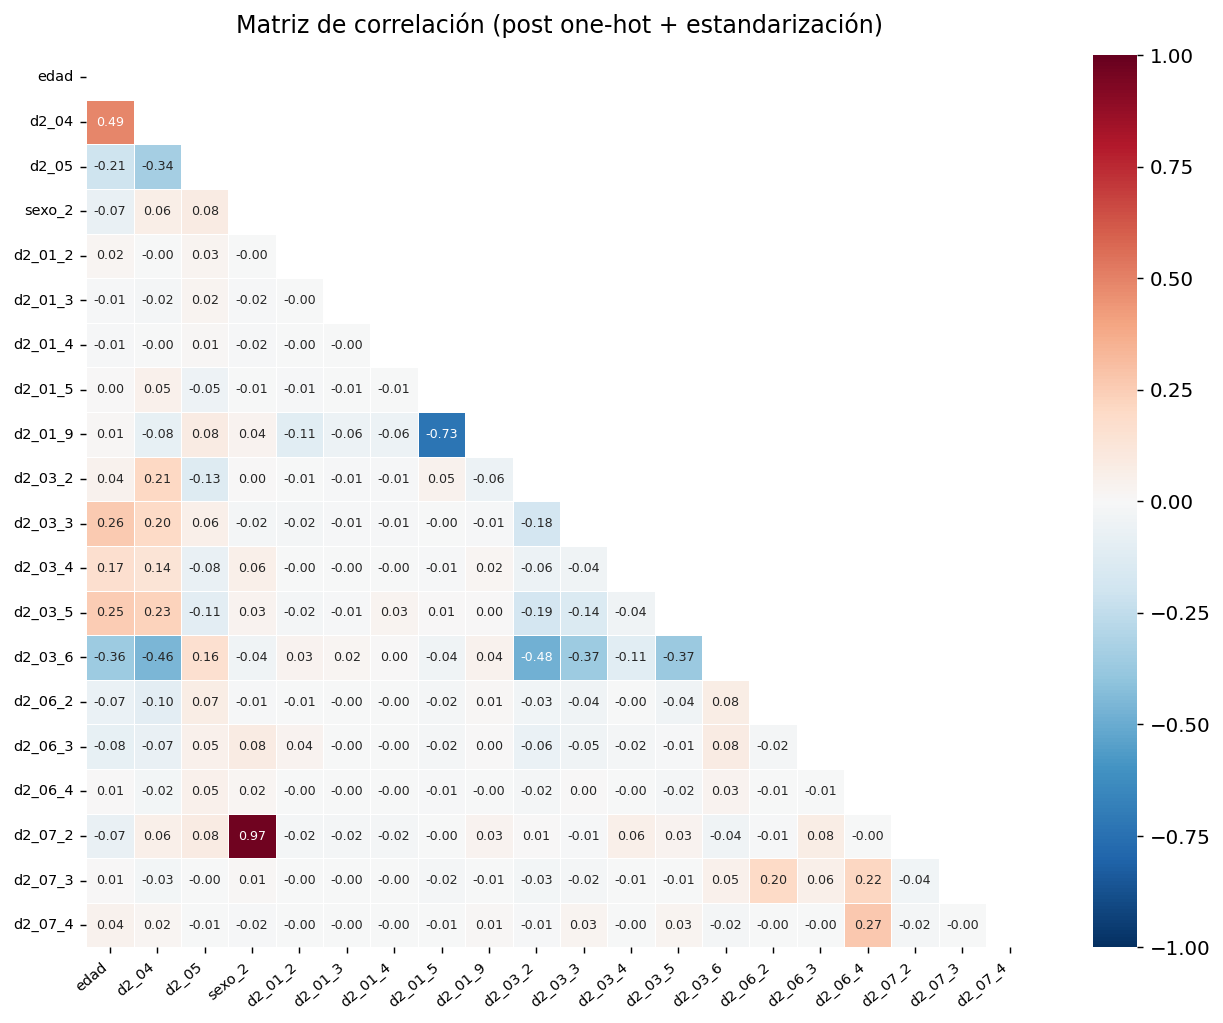

In [12]:
# ── Clasificación de variables ───────────────────────────────────────────────
NUMERIC  = ['edad', 'd2_04', 'd2_05']          # continua / ordinal con orden real
NOMINAL  = ['sexo', 'd2_01', 'd2_03', 'd2_06', 'd2_07']   # categorías sin orden

# ── One-hot encoding para nominales ─────────────────────────────────────────
df_enc = df[FEATURES + [TARGET]].copy()
df_enc[NOMINAL] = df_enc[NOMINAL].astype(int).astype(str)   # evitar que pandas las trate como número
df_enc = pd.get_dummies(df_enc, columns=NOMINAL, drop_first=True)

# Columnas que entran al PCA (todo menos el target)
pca_cols = [c for c in df_enc.columns if c != TARGET]
X_raw    = df_enc[pca_cols].values.astype(float)
y        = df_enc[TARGET].values

# ── StandardScaler sobre todo (ya sin códigos nominales crudos) ───────────────
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print(f'Dimensión antes del encoding : {len(FEATURES)} variables')
print(f'Dimensión después del encoding: {X.shape[1]} columnas (one-hot expandió las nominales)')
print(f'Columnas PCA: {pca_cols}')

# Actualizar label_list para las gráficas posteriores
label_list = pca_cols

# ── Matriz de correlación ────────────────────────────────────────────────────
corr = pd.DataFrame(X, columns=pca_cols).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    xticklabels=pca_cols, yticklabels=pca_cols, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Matriz de correlación (post one-hot + estandarización)', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('corr_pca.png', bbox_inches='tight')
plt.show()


## 3. Scree plot — ¿Cuántos componentes retener?

El **scree plot** muestra la varianza explicada por cada componente principal.  
La regla del codo (*elbow rule*) sugiere retener los componentes antes de que la curva se aplane.

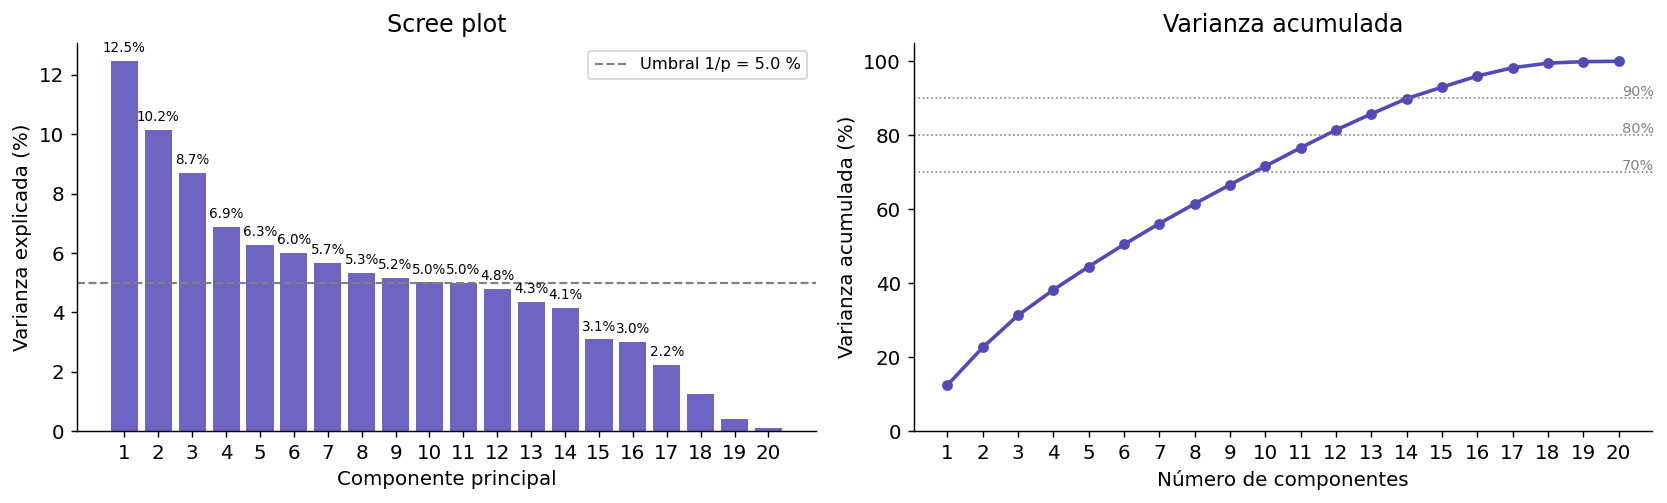

      Varianza explicada (%)  Varianza acumulada (%)  Eigenvalue
PC1                    12.46                   12.46       2.492
PC2                    10.16                   22.61       2.032
PC3                     8.69                   31.31       1.739
PC4                     6.89                   38.19       1.378
PC5                     6.28                   44.47       1.256
PC6                     6.00                   50.47       1.201
PC7                     5.65                   56.12       1.131
PC8                     5.33                   61.46       1.066
PC9                     5.16                   66.62       1.033
PC10                    5.01                   71.63       1.002
PC11                    4.98                   76.61       0.997
PC12                    4.80                   81.41       0.961
PC13                    4.35                   85.76       0.870
PC14                    4.14                   89.90       0.829
PC15                    3

In [14]:
pca_full = PCA().fit(X)
ev      = pca_full.explained_variance_ratio_
ev_cum  = np.cumsum(ev)
n_comp  = X.shape[1]          # ahora 20 (post one-hot)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Izquierda: varianza individual ---
eigenvalues = pca_full.explained_variance_
axes[0].bar(range(1, n_comp+1), ev * 100, color=C0, alpha=0.85)
axes[0].axhline(100 / n_comp, color='gray', ls='--', lw=1.2,
                label=f'Umbral 1/p = {100/n_comp:.1f} %')
axes[0].set_xticks(range(1, n_comp+1))
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot')
axes[0].legend(fontsize=9)
for i, v in enumerate(ev):
    if v * 100 > 2:    # anotar solo las barras más grandes para no saturar
        axes[0].text(i+1, v*100+0.2, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=7.5)

# --- Derecha: varianza acumulada ---
axes[1].plot(range(1, n_comp+1), ev_cum * 100, 'o-', color=C0, lw=2, ms=5)
for threshold in [70, 80, 90]:
    axes[1].axhline(threshold, color='gray', ls=':', lw=0.9)
    axes[1].text(n_comp+0.1, threshold+0.5, f'{threshold}%', fontsize=8, color='gray')
axes[1].set_xticks(range(1, n_comp+1))
axes[1].set_ylim(0, 105)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')

plt.tight_layout()
plt.savefig('scree_pca.png', bbox_inches='tight')
plt.show()

# Tabla resumen
summary = pd.DataFrame({
    'Varianza explicada (%)': (ev * 100).round(2),
    'Varianza acumulada (%)': (ev_cum * 100).round(2),
    'Eigenvalue':             eigenvalues.round(3),
}, index=[f'PC{i}' for i in range(1, n_comp+1)])
print(summary.to_string())


## 4. Loadings (cargas de las variables)

Los **loadings** indican cuánto contribuye cada variable original a cada componente principal.  
Un loading alto (positivo o negativo) significa que esa variable tiene mucho peso en ese componente.

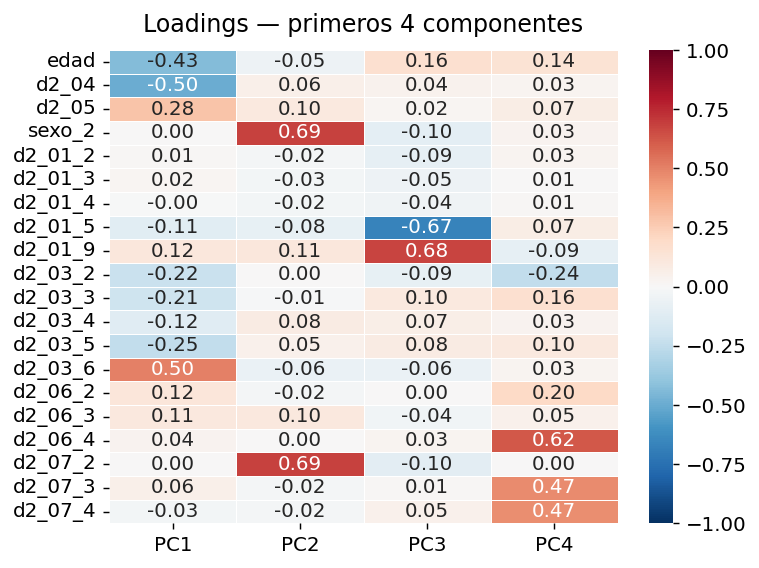

           PC1    PC2    PC3    PC4
edad    -0.434 -0.050  0.160  0.144
d2_04   -0.497  0.057  0.042  0.026
d2_05    0.284  0.097  0.020  0.073
sexo_2   0.004  0.685 -0.099  0.034
d2_01_2  0.011 -0.021 -0.091  0.026
d2_01_3  0.021 -0.027 -0.050  0.007
d2_01_4 -0.000 -0.024 -0.044  0.012
d2_01_5 -0.110 -0.084 -0.667  0.072
d2_01_9  0.117  0.111  0.676 -0.089
d2_03_2 -0.223  0.004 -0.086 -0.242
d2_03_3 -0.209 -0.010  0.101  0.158
d2_03_4 -0.123  0.081  0.065  0.032
d2_03_5 -0.250  0.052  0.082  0.098
d2_03_6  0.505 -0.063 -0.063  0.025
d2_06_2  0.121 -0.021  0.003  0.199
d2_06_3  0.106  0.102 -0.037  0.051
d2_06_4  0.036  0.005  0.027  0.617
d2_07_2  0.002  0.685 -0.103  0.004
d2_07_3  0.058 -0.020  0.013  0.472
d2_07_4 -0.026 -0.018  0.048  0.466


In [15]:
N_SHOW = 4   # componentes a mostrar en loadings

loadings = pd.DataFrame(
    pca_full.components_[:N_SHOW].T,
    index=label_list,
    columns=[f'PC{i+1}' for i in range(N_SHOW)]
)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Loadings — primeros 4 componentes', pad=10)
plt.tight_layout()
plt.savefig('loadings_pca.png', bbox_inches='tight')
plt.show()

print(loadings.round(3).to_string())


## 5. Biplot PC1 vs PC2

El **biplot** superpone:
- **Puntos** (individuos): posición de cada encuestado en el espacio PC1–PC2, coloreados por `propension_12m`
- **Flechas** (loadings): dirección e intensidad con que cada variable original jala hacia cada componente

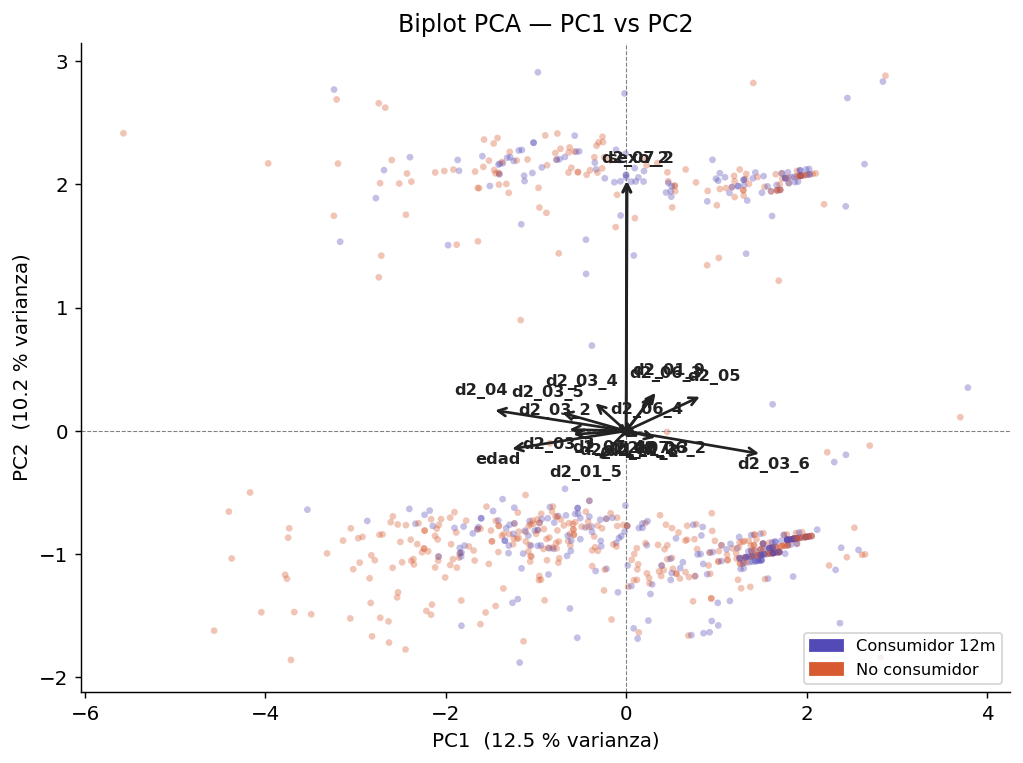

In [16]:
pca2 = PCA(n_components=2).fit(X)
Z    = pca2.transform(X)

# Escala de flechas: proporcional a la desviación de los scores
arrow_scale = 3.0

fig, ax = plt.subplots(figsize=(8, 6))

# Puntos — muestra aleatoria para no saturar (máx 800 puntos)
rng   = np.random.default_rng(42)
idx   = rng.choice(len(Z), size=min(800, len(Z)), replace=False)
colors = np.where(y[idx] == 1, C0, C1)
ax.scatter(Z[idx, 0], Z[idx, 1], c=colors, alpha=0.35, s=14, linewidths=0)

# Flechas de loadings
for i, feat in enumerate(label_list):
    vx = pca2.components_[0, i] * arrow_scale
    vy = pca2.components_[1, i] * arrow_scale
    ax.annotate('', xy=(vx, vy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#222', lw=1.5))
    offset_x = 0.12 if vx >= 0 else -0.12
    offset_y = 0.12 if vy >= 0 else -0.12
    ax.text(vx + offset_x, vy + offset_y, feat,
            fontsize=9, ha='center', color='#222', fontweight='bold')

var1, var2 = pca2.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1  ({var1:.1f} % varianza)')
ax.set_ylabel(f'PC2  ({var2:.1f} % varianza)')
ax.set_title('Biplot PCA — PC1 vs PC2')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvline(0, color='gray', lw=0.6, ls='--')

legend_handles = [
    mpatches.Patch(color=C0, label='Consumidor 12m'),
    mpatches.Patch(color=C1, label='No consumidor'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('biplot_pca.png', bbox_inches='tight')
plt.show()


## 6. Distribución en PC1 por grupo

¿Se separan consumidores y no consumidores a lo largo del primer componente principal?

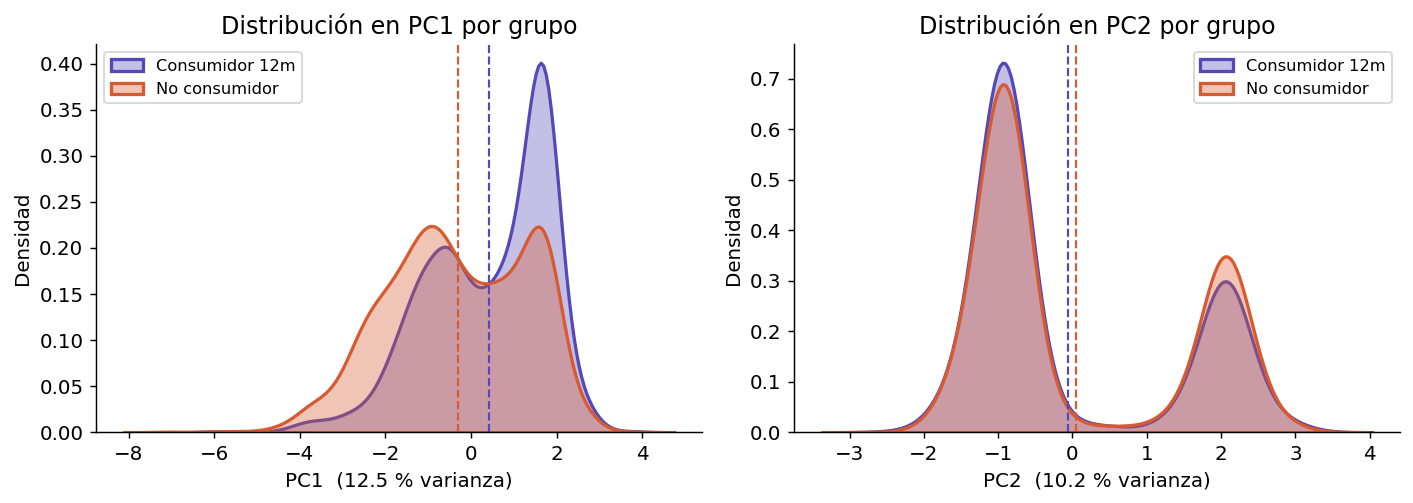

PC1: media consumidores=0.419 | media no-consumidores=-0.311 | t=14.55 | p=0.0000
PC2: media consumidores=-0.066 | media no-consumidores=0.049 | t=-2.48 | p=0.0133


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pc_idx, pc_name in zip(axes, [0, 1], ['PC1', 'PC2']):
    for val, color, label in [(1, C0, 'Consumidor 12m'), (0, C1, 'No consumidor')]:
        mask = y == val
        sns.kdeplot(Z[mask, pc_idx], ax=ax, color=color, fill=True,
                    alpha=0.35, linewidth=1.8, label=label)
        ax.axvline(Z[mask, pc_idx].mean(), color=color, ls='--', lw=1.2)

    var_pct = pca_full.explained_variance_ratio_[pc_idx] * 100
    ax.set_xlabel(f'{pc_name}  ({var_pct:.1f} % varianza)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Distribución en {pc_name} por grupo')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kde_pca.png', bbox_inches='tight')
plt.show()

# Test de medias
from scipy import stats
for pc_idx, pc_name in [(0, 'PC1'), (1, 'PC2')]:
    g1 = Z[y == 1, pc_idx]
    g0 = Z[y == 0, pc_idx]
    t, p = stats.ttest_ind(g1, g0)
    print(f'{pc_name}: media consumidores={g1.mean():.3f} | '
          f'media no-consumidores={g0.mean():.3f} | t={t:.2f} | p={p:.4f}')


## 7. Contribución de cada variable a PC1 y PC2

La **contribución** (en %) indica cuánto del componente es "explicado" por cada variable original.

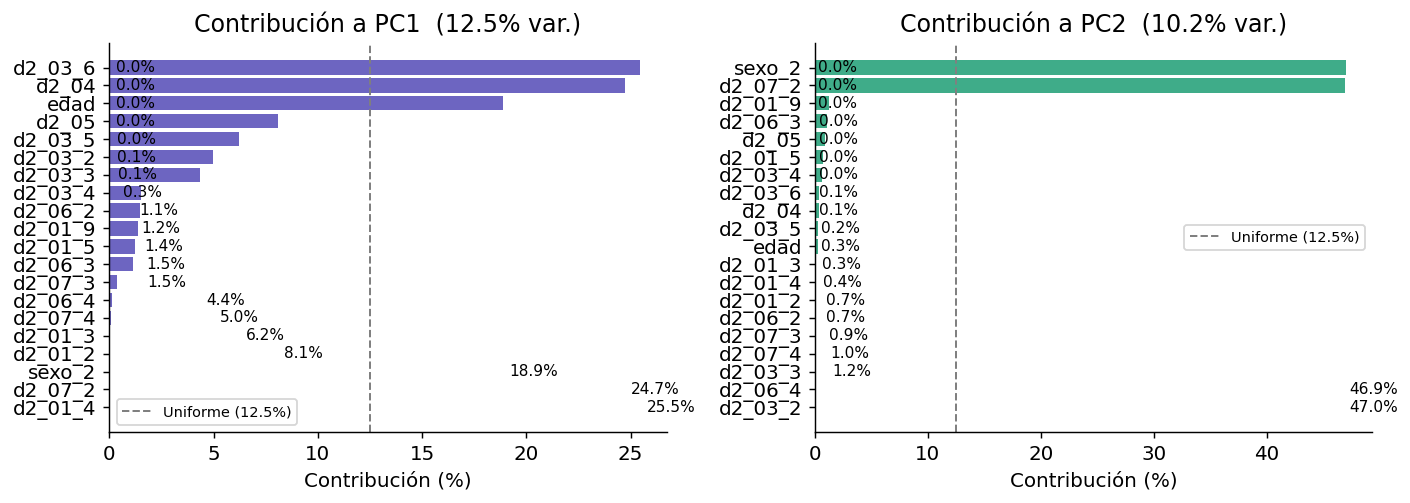

In [18]:
PALETTE4 = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pc_idx, pc_name, color in zip(axes, [0, 1], ['PC1', 'PC2'], PALETTE4):
    comp    = pca_full.components_[pc_idx]
    contrib = comp**2 / (comp**2).sum() * 100          # % de contribución
    order   = np.argsort(contrib)[::-1]
    labels  = [label_list[i] for i in order]
    vals    = contrib[order]

    bars = ax.barh(labels[::-1], vals[::-1], color=color, alpha=0.85)
    ref  = 100 / len(FEATURES)                         # contribución uniforme
    ax.axvline(ref, color='gray', ls='--', lw=1.1,
               label=f'Uniforme ({ref:.1f}%)')
    ax.set_xlabel('Contribución (%)')
    ax.set_title(f'Contribución a {pc_name}  '
                 f'({pca_full.explained_variance_ratio_[pc_idx]*100:.1f}% var.)')
    ax.legend(fontsize=8)
    for bar, v in zip(bars[::-1], vals[::-1]):
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('contrib_pca.png', bbox_inches='tight')
plt.show()


## 8. Exportar scores para uso posterior

In [19]:
N_KEEP = 3   # componentes a guardar en el CSV de scores

pca_final = PCA(n_components=N_KEEP).fit(X)
Z_final   = pca_final.transform(X)

scores_df = df[[TARGET]].copy()
for i in range(N_KEEP):
    scores_df[f'PC{i+1}'] = Z_final[:, i]

out_path = PROJECT_ROOT / 'data' / 'processed' / 'pca_scores.csv'
scores_df.to_csv(out_path, index=False)

print(f'Scores guardados en: {out_path}')
print(f'Shape: {scores_df.shape}')
print(f'Varianza explicada (3 PCs): {pca_final.explained_variance_ratio_.sum()*100:.1f} %')
print()
print('=== Resumen final ===')
resumen = pd.DataFrame({
    'Varianza explicada (%)': (pca_full.explained_variance_ratio_ * 100).round(2),
    'Varianza acumulada (%)': (np.cumsum(pca_full.explained_variance_ratio_) * 100).round(2),
    'Eigenvalue':              pca_full.explained_variance_.round(3),
}, index=[f'PC{i+1}' for i in range(n_comp)])
print(resumen.to_string())


Scores guardados en: /Users/santi/Documents/EAFIT/2026-1/Ciencia de los Datos/Repo/colombia-marijuana-revenue-model/data/processed/pca_scores.csv
Shape: (3844, 4)
Varianza explicada (3 PCs): 31.3 %

=== Resumen final ===
      Varianza explicada (%)  Varianza acumulada (%)  Eigenvalue
PC1                    12.46                   12.46       2.492
PC2                    10.16                   22.61       2.032
PC3                     8.69                   31.31       1.739
PC4                     6.89                   38.19       1.378
PC5                     6.28                   44.47       1.256
PC6                     6.00                   50.47       1.201
PC7                     5.65                   56.12       1.131
PC8                     5.33                   61.46       1.066
PC9                     5.16                   66.62       1.033
PC10                    5.01                   71.63       1.002
PC11                    4.98                   76.61       0.997